In [3]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/My Drive/Colab Notebooks/')

Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [20]:
df =pd.read_csv('/content/drive/My Drive/Sarana Air Jawa Barat/dinkes-od_17538_persentase_sarana_air_minum_dengan_resiko_rendah_s_v1.csv', sep=',')
print("Number of datapoints:", len(df))
df.head()

Number of datapoints: 81


,id,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,persentase_sarana_air,satuan,tahun
0,1,32,JAWA BARAT,3201,KABUPATEN BOGOR,82.5,PERSEN,2019
1,2,32,JAWA BARAT,3202,KABUPATEN SUKABUMI,66.4,PERSEN,2019
2,3,32,JAWA BARAT,3203,KABUPATEN CIANJUR,53.4,PERSEN,2019
3,4,32,JAWA BARAT,3204,KABUPATEN BANDUNG,39.0,PERSEN,2019
4,5,32,JAWA BARAT,3205,KABUPATEN GARUT,0.0,PERSEN,2019


In [21]:
df.describe()

,id,kode_provinsi,kode_kabupaten_kota,persentase_sarana_air,tahun
count,81.000000,81.0,81.000000,81.000000,81.000000
mean,41.000000,32.0,3231.333333,1133.547531,2020.000000
std,23.526581,0.0,31.396258,9588.756827,0.821584
min,1.000000,32.0,3201.000000,0.000000,2019.000000
25%,21.000000,32.0,3207.000000,58.400000,2019.000000
50%,41.000000,32.0,3214.000000,71.800000,2020.000000
75%,61.000000,32.0,3273.000000,84.100000,2021.000000
max,81.000000,32.0,3279.000000,86366.700000,2021.000000


In [22]:
df.shape

(81, 8)

In [23]:
df = df.dropna()
print("Jumlah records setelah menghapus records yang mempunyai nilai hilang adalah:", len(df))

Jumlah records setelah menghapus records yang mempunyai nilai hilang adalah: 81


In [24]:
# Hapus kolom yang tidak diperlukan
df = df.drop(columns=['id', 'nama_provinsi', 'nama_kabupaten_kota', 'satuan'])

In [27]:
def determine_status(persentase):
    if persentase >= 80:
        return "0"
    elif persentase >= 50:
        return "1"
    elif persentase >= 30:
        return "2"
    else:
        return "3"

df['status_air'] = df['persentase_sarana_air'].apply(determine_status)

In [28]:
df.head()

,kode_provinsi,kode_kabupaten_kota,persentase_sarana_air,tahun,status_air
0,32,3201,82.5,2019,0
1,32,3202,66.4,2019,1
2,32,3203,53.4,2019,1
3,32,3204,39.0,2019,2
4,32,3205,0.0,2019,3


Relative Plot Of Some Selected Features: A Data Subset


<Figure size 640x480 with 0 Axes>

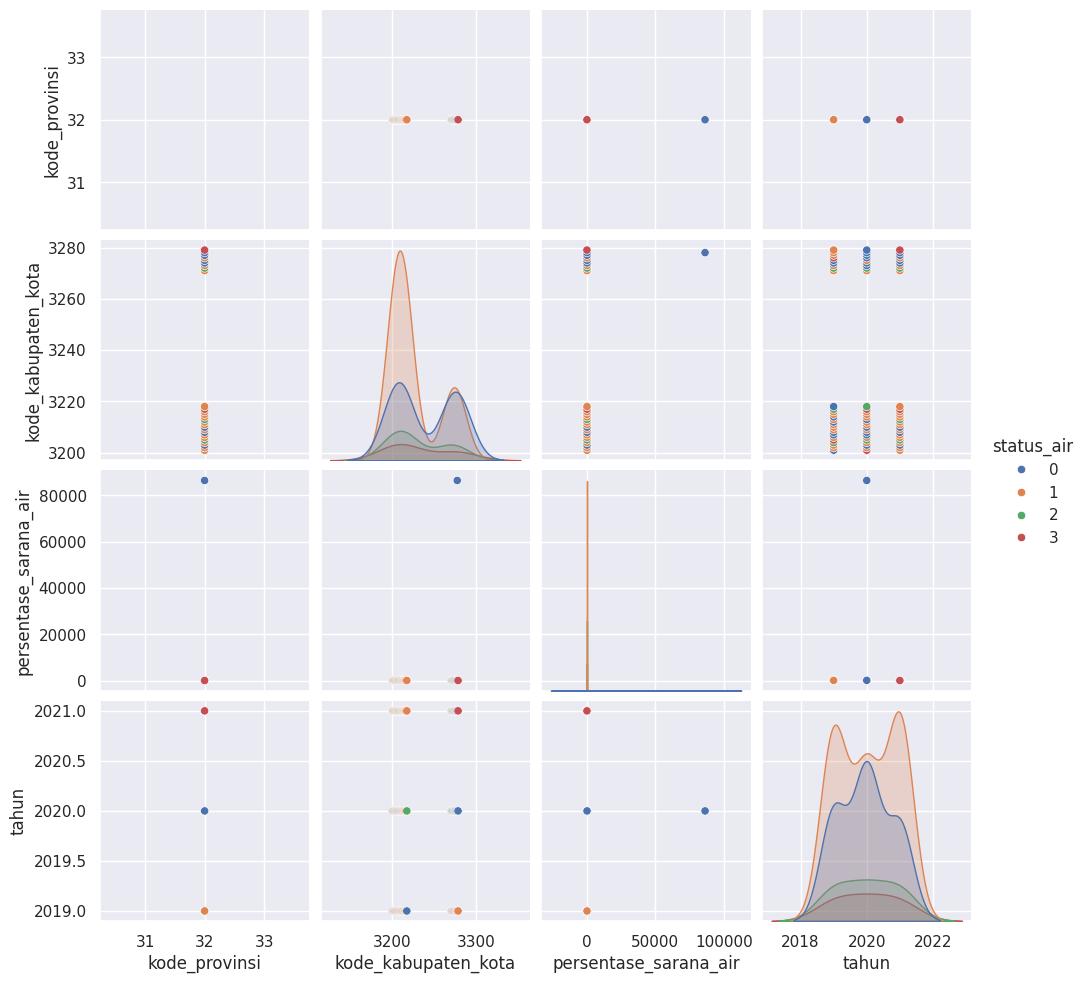

In [29]:
To_Plot = ["kode_provinsi", "kode_kabupaten_kota", "persentase_sarana_air", "tahun", "status_air"]

print("Relative Plot Of Some Selected Features: A Data Subset")
plt.figure()

sns.pairplot(df[To_Plot], hue="status_air")

plt.show()

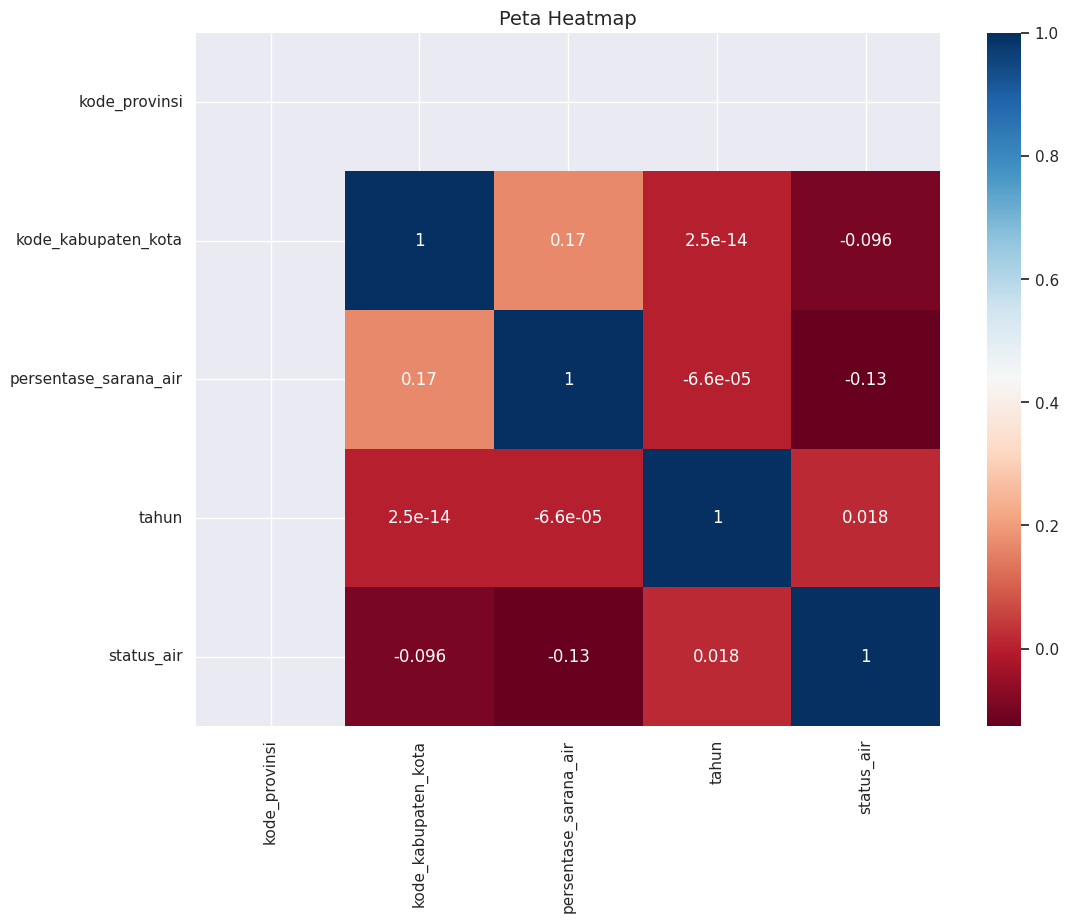

In [30]:
plt.figure(figsize=(12,9))
sns.heatmap( df.corr() ,annot=True,cmap='RdBu')
plt.title('Peta Heatmap',fontsize=14)
plt.yticks(rotation =0)
plt.show()

In [31]:
scaler = StandardScaler()
df_std = scaler.fit_transform(df)

In [32]:
df_std = pd.DataFrame(data = df_std,columns = df.columns)

In [33]:
wcss = []
for i in range(1,20):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(df_std)
    wcss.append(kmeans.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

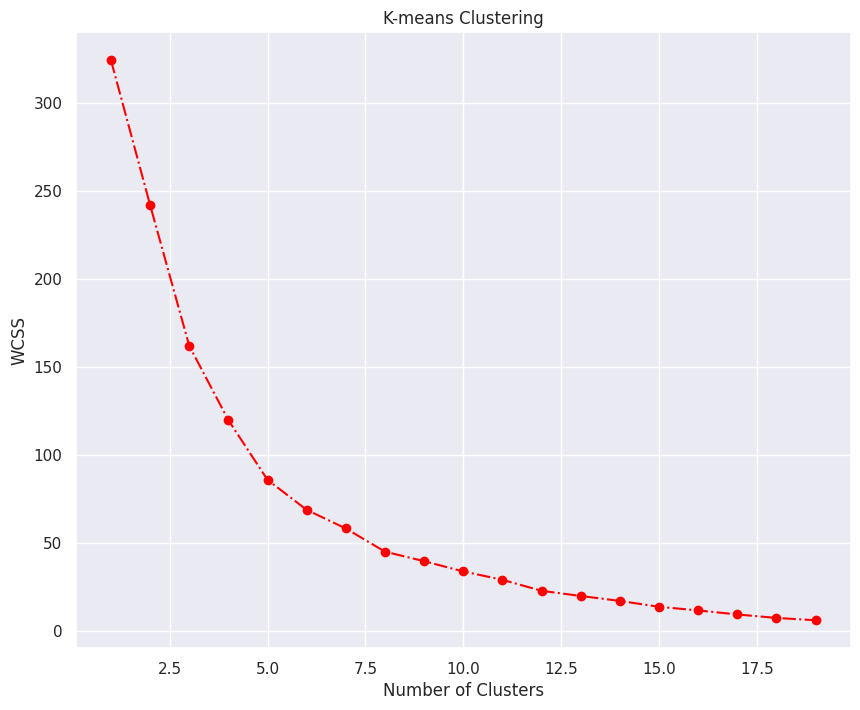

In [35]:
plt.figure(figsize = (10,8))
plt.plot(range(1, 20), wcss, marker = 'o', linestyle = '-.',color='red')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('K-means Clustering')
plt.show()

In [41]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)

In [43]:
kmeans.fit(df_std)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=4, random_state=42)

In [44]:
df_segm_kmeans= df_std.copy()
df_std["Segment K-means"] = kmeans.labels_
df_std.head()

,kode_provinsi,kode_kabupaten_kota,persentase_sarana_air,tahun,status_air,Segment K-means
0,0.0,-0.972165,-0.110295,-1.224745,-1.102260,2
1,0.0,-0.940115,-0.111985,-1.224745,0.072517,2
2,0.0,-0.908066,-0.113349,-1.224745,0.072517,2
3,0.0,-0.876016,-0.114860,-1.224745,1.247294,2
4,0.0,-0.843967,-0.118953,-1.224745,2.422071,2


In [45]:
features = ["kode_provinsi", "kode_kabupaten_kota", "persentase_sarana_air", "tahun", "status_air"]
X = df[features]

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
kmeans.fit(X_std)

cluster_labels = kmeans.labels_
df['Cluster'] = cluster_labels

# Evaluasi performa clustering menggunakan Silhouette Score
silhouette_avg = silhouette_score(X_std, cluster_labels)
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.36675433666345286


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [46]:
df_segm_analisis = df_std.groupby(['Segment K-means']).mean()
df_segm_analisis

,kode_provinsi,kode_kabupaten_kota,persentase_sarana_air,tahun,status_air
Segment K-means,,,,,
0,0.0,-0.695374,-0.112844,1.002064,0.446310
1,0.0,1.395792,-0.111382,0.000000,-0.108218
2,0.0,-0.702749,-0.111429,-0.688919,-0.184465
3,0.0,1.495638,8.944247,0.000000,-1.102260


In [47]:
df

,kode_provinsi,kode_kabupaten_kota,persentase_sarana_air,tahun,status_air,Cluster
0,32,3201,82.50,2019,0,0
1,32,3202,66.40,2019,1,0
2,32,3203,53.40,2019,1,0
3,32,3204,39.00,2019,2,0
4,32,3205,0.00,2019,3,0
...,...,...,...,...,...,...
76,32,3275,81.40,2021,0,1
77,32,3276,74.84,2021,1,1
78,32,3277,97.80,2021,0,1
79,32,3278,86.90,2021,0,1
